# Checking effects of hybrid quantile mapping approach.

This notebook tests our implementation of a hybrid quantile mapping approach, and checks how it is different from parametric and nonparametric quantile mapping. This hybrid approach is a combination of parametric and nonparametric quantile mapping. It does nonparametric quantile mapping most of the time, but uses parametric quantile mapping when a detrended value is outside the range of the modeled historical (which is what is used to construct the mapping between the model and observations). Because the modeled future scenario is detrended, this doesn't happen that often, but it does happen sometimes.

# 0. Set up workspace

In [1]:
import duckdb
import geopandas as gpd
import icechunk
import matplotlib.pyplot as plt
import xarray as xr

from srm import catalog
from srm.bcsd_config import BCSDConfig, PipelineOptions
from srm.pipeline import BCSDPipeline

# 1. Define Configuration

we'll configure a BCSD run for:
- GCM: CESM2-WACCM
- Variable: tas (temperature)
- Scenario: SSP245
- Region: South Africa
- Environment: qa (for testing)

In [2]:
# Define South Africa bounds
df = duckdb.sql(
    """
    install httpfs; load httpfs;
    install spatial; load spatial;
    SELECT name, ST_AsText(geom) as geometry
    FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json')
    WHERE NAME = 'Lesotho'
    """
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
country_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds with 2-degree buffer
lon_min, lat_min, lon_max, lat_max = country_geom.total_bounds
bounds = [lat_min - 2, lat_max + 2, lon_min - 2, lon_max + 2]
bounds = [round(entry, 2) for entry in bounds]

print(f"Country subset bounds: {bounds}")

Country subset bounds: [np.float64(-32.64), np.float64(-26.58), np.float64(25.05), np.float64(31.39)]


# 2. Run pipeline for different variables

### DTR

In [6]:
variable = "dtr"

In [7]:
# Create configuration
config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable=variable,
    ensemble_member="007",
    scenario="SSP245",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
    mapping_type="nonparametric_hybrid_2sided",
)

options = PipelineOptions(
    scratch_dir="s3://carbonplan-scratch/srm/bcsd-cache/",
    output_dir="s3://carbonplan-scratch/srm/outputs/",
    environment="qa",
    version="test007_nonparametric_2sided",
    verbose=True,
    rechunk_workflow=True,
    apply_ocean_mask=False,
    save_intermediate=True,
)

print(f"Run ID: {config.run_id}")
print(f"Config hash: {config.config_hash}")
print(f"Detrend data: {config.detrend_data}")

Run ID: CESM2-WACCM_dtr_007_SSP245_subset
Config hash: e027d1d40b90
Detrend data: True


In [8]:
# Initialize pipeline
pipeline = BCSDPipeline(config, options)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path_dtr = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path_dtr}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path_dtr = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path_dtr}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path_dtr = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path_dtr}")

Stage 1: Prepare observations (regrid ERA5 to GCM grid)
✓ Observations cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/test007_nonparametric_2sided/obs/CESM2-WACCM/dtr/lat-32.64to-26.58_lon25.05to31.39/obs_regridded.icechunk

Stage 2: Fit historical (debias and downscale historical period)
✓ Historical cached at: s3://carbonplan-scratch/srm/outputs/qa/test007_nonparametric_2sided/historical/CESM2-WACCM/dtr/001/lat-32.64to-26.58_lon25.05to31.39/12ae5fc3/historical.icechunk

Stage 3: Transform scenario (debias and downscale future)
✓ Scenario output at: s3://carbonplan-scratch/srm/outputs/qa/test007_nonparametric_2sided/ssp245/CESM2-WACCM/dtr/007/lat-32.64to-26.58_lon25.05to31.39/12ae5fc3/ssp245.icechunk


### tasmax

In [9]:
variable = "tasmax"

In [10]:
# Create configuration
config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable=variable,
    ensemble_member="007",
    scenario="SSP245",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
    mapping_type="nonparametric_hybrid_2sided",
)

options = PipelineOptions(
    scratch_dir="s3://carbonplan-scratch/srm/bcsd-cache/",
    output_dir="s3://carbonplan-scratch/srm/outputs/",
    environment="qa",
    version="test007_nonparametric_2sided",
    verbose=True,
    rechunk_workflow=True,
    apply_ocean_mask=False,
    save_intermediate=True,
)

print(f"Run ID: {config.run_id}")
print(f"Config hash: {config.config_hash}")
print(f"Detrend data: {config.detrend_data}")

Run ID: CESM2-WACCM_tasmax_007_SSP245_subset
Config hash: f01a36599103
Detrend data: True


In [11]:
# Initialize pipeline
pipeline = BCSDPipeline(config, options)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path_tasmax = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path_tasmax}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path_tasmax = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path_tasmax}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path_tasmax = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path_tasmax}")

Stage 1: Prepare observations (regrid ERA5 to GCM grid)
✓ Observations cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/test007_nonparametric_2sided/obs/CESM2-WACCM/tasmax/lat-32.64to-26.58_lon25.05to31.39/obs_regridded.icechunk

Stage 2: Fit historical (debias and downscale historical period)
✓ Historical cached at: s3://carbonplan-scratch/srm/outputs/qa/test007_nonparametric_2sided/historical/CESM2-WACCM/tasmax/001/lat-32.64to-26.58_lon25.05to31.39/0e480a86/historical.icechunk

Stage 3: Transform scenario (debias and downscale future)
✓ Scenario output at: s3://carbonplan-scratch/srm/outputs/qa/test007_nonparametric_2sided/ssp245/CESM2-WACCM/tasmax/007/lat-32.64to-26.58_lon25.05to31.39/0e480a86/ssp245.icechunk


### tas

In [12]:
variable = "tas"

In [13]:
# Create configuration
config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable=variable,
    ensemble_member="001",
    scenario="SSP245",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
    mapping_type="nonparametric_hybrid_2sided",
)

options = PipelineOptions(
    scratch_dir="s3://carbonplan-scratch/srm/bcsd-cache/",
    output_dir="s3://carbonplan-scratch/srm/outputs/",
    environment="qa",
    version="test006_nonparametric_2sided",
    verbose=True,
    rechunk_workflow=True,
    apply_ocean_mask=False,
    save_intermediate=True,
)

print(f"Run ID: {config.run_id}")
print(f"Config hash: {config.config_hash}")
print(f"Detrend data: {config.detrend_data}")

Run ID: CESM2-WACCM_tas_001_SSP245_subset
Config hash: 4cf118a9d2ee
Detrend data: True


In [14]:
# Initialize pipeline
pipeline = BCSDPipeline(config, options)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path_tas = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path_tas}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path_tas = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path_tas}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path_tas = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path_tas}")

Stage 1: Prepare observations (regrid ERA5 to GCM grid)
✓ Observations cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/test006_nonparametric_2sided/obs/CESM2-WACCM/tas/lat-32.64to-26.58_lon25.05to31.39/obs_regridded.icechunk

Stage 2: Fit historical (debias and downscale historical period)
✓ Historical cached at: s3://carbonplan-scratch/srm/outputs/qa/test006_nonparametric_2sided/historical/CESM2-WACCM/tas/r1i1p1f1/lat-32.64to-26.58_lon25.05to31.39/0e480a86/historical.icechunk

Stage 3: Transform scenario (debias and downscale future)
✓ Scenario output at: s3://carbonplan-scratch/srm/outputs/qa/test006_nonparametric_2sided/ssp245/CESM2-WACCM/tas/001/lat-32.64to-26.58_lon25.05to31.39/0e480a86/ssp245.icechunk


### pr

In [15]:
variable = "pr"

In [16]:
# Create configuration
config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable=variable,
    ensemble_member="001",
    scenario="SSP245",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
    mapping_type="nonparametric_hybrid_2sided",
)

options = PipelineOptions(
    scratch_dir="s3://carbonplan-scratch/srm/bcsd-cache/",
    output_dir="s3://carbonplan-scratch/srm/outputs/",
    environment="qa",
    version="test006_nonparametric_2sided",
    verbose=True,
    rechunk_workflow=True,
    apply_ocean_mask=False,
    save_intermediate=True,
)

print(f"Run ID: {config.run_id}")
print(f"Config hash: {config.config_hash}")
print(f"Detrend data: {config.detrend_data}")

Run ID: CESM2-WACCM_pr_001_SSP245_subset
Config hash: aa3abf054a87
Detrend data: False


In [17]:
# Initialize pipeline
pipeline = BCSDPipeline(config, options)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path_pr = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path_pr}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path_pr = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path_pr}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path_pr = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path_pr}")

Stage 1: Prepare observations (regrid ERA5 to GCM grid)
✓ Observations cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/test006_nonparametric_2sided/obs/CESM2-WACCM/pr/lat-32.64to-26.58_lon25.05to31.39/obs_regridded.icechunk

Stage 2: Fit historical (debias and downscale historical period)
✓ Historical cached at: s3://carbonplan-scratch/srm/outputs/qa/test006_nonparametric_2sided/historical/CESM2-WACCM/pr/r1i1p1f1/lat-32.64to-26.58_lon25.05to31.39/aae0e80a/historical.icechunk

Stage 3: Transform scenario (debias and downscale future)
✓ Scenario output at: s3://carbonplan-scratch/srm/outputs/qa/test006_nonparametric_2sided/ssp245/CESM2-WACCM/pr/001/lat-32.64to-26.58_lon25.05to31.39/aae0e80a/ssp245.icechunk


### rsds

In [18]:
variable = "rsds"

In [19]:
# Create configuration
config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable=variable,
    ensemble_member="001",
    scenario="SSP245",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
    mapping_type="nonparametric_hybrid_2sided",
)

options = PipelineOptions(
    scratch_dir="s3://carbonplan-scratch/srm/bcsd-cache/",
    output_dir="s3://carbonplan-scratch/srm/outputs/",
    environment="qa",
    version="test006_nonparametric_2sided",
    verbose=True,
    rechunk_workflow=True,
    apply_ocean_mask=False,
    save_intermediate=True,
)

print(f"Run ID: {config.run_id}")
print(f"Config hash: {config.config_hash}")
print(f"Detrend data: {config.detrend_data}")

Run ID: CESM2-WACCM_rsds_001_SSP245_subset
Config hash: 26b8d5038223
Detrend data: True


In [20]:
# Initialize pipeline
pipeline = BCSDPipeline(config, options)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path_rsds = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path_rsds}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path_rsds = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path_rsds}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path_rsds = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path_rsds}")

Stage 1: Prepare observations (regrid ERA5 to GCM grid)
✓ Observations cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/test006_nonparametric_2sided/obs/CESM2-WACCM/rsds/lat-32.64to-26.58_lon25.05to31.39/obs_regridded.icechunk

Stage 2: Fit historical (debias and downscale historical period)
✓ Historical cached at: s3://carbonplan-scratch/srm/outputs/qa/test006_nonparametric_2sided/historical/CESM2-WACCM/rsds/r1i1p1f1/lat-32.64to-26.58_lon25.05to31.39/12ae5fc3/historical.icechunk

Stage 3: Transform scenario (debias and downscale future)
✓ Scenario output at: s3://carbonplan-scratch/srm/outputs/qa/test006_nonparametric_2sided/ssp245/CESM2-WACCM/rsds/001/lat-32.64to-26.58_lon25.05to31.39/12ae5fc3/ssp245.icechunk


### hurs

In [3]:
variable = "hurs"

In [4]:
# Create configuration
config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable=variable,
    ensemble_member="001",
    scenario="SSP245",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
    mapping_type="nonparametric_hybrid_2sided",
)

options = PipelineOptions(
    scratch_dir="s3://carbonplan-scratch/srm/bcsd-cache/",
    output_dir="s3://carbonplan-scratch/srm/outputs/",
    environment="qa",
    version="test007_nonparametric_2sided",
    verbose=True,
    rechunk_workflow=True,
    apply_ocean_mask=False,
    save_intermediate=True,
)

print(f"Run ID: {config.run_id}")
print(f"Config hash: {config.config_hash}")
print(f"Detrend data: {config.detrend_data}")

Run ID: CESM2-WACCM_hurs_001_SSP245_subset
Config hash: 863058a49fa5
Detrend data: True


In [5]:
# Initialize pipeline
pipeline = BCSDPipeline(config, options)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path_hurs = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path_hurs}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path_hurs = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path_hurs}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path_hurs = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path_hurs}")

Stage 1: Prepare observations (regrid ERA5 to GCM grid)
✓ Observations cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/test007_nonparametric_2sided/obs/CESM2-WACCM/hurs/lat-32.64to-26.58_lon25.05to31.39/obs_regridded.icechunk

Stage 2: Fit historical (debias and downscale historical period)


/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:532: UserWarning: obs contains inf or nan values. Not all debiasers support missing values and their presence might lead to infs or nans inside of the debiased values. Consider infilling the missing values.
  obs, cm_hist, cm_future = self._check_inputs_and_convert_if_possible(
/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:562: UserWarning: The debiaser output contains inf or nan values. This might be due to inf or nan values inside the input, or to a problem of the debiaser for the given dataset at hand. It is recommended to check the output carefully
  self._check_output(output)


✓ Historical cached at: s3://carbonplan-scratch/srm/outputs/qa/test007_nonparametric_2sided/historical/CESM2-WACCM/hurs/r1i1p1f1/lat-32.64to-26.58_lon25.05to31.39/0e480a86/historical.icechunk

Stage 3: Transform scenario (debias and downscale future)


/scratch/synced/src/srm/pipeline.py:244: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  result = xr.concat(
/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:532: UserWarning: obs contains inf or nan values. Not all debiasers support missing values and their presence might lead to infs or nans inside of the debiased values. Consider infilling the missing values.
  obs, cm_hist, cm_future = self._check_inputs_and_convert_if_possible(
/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:562: UserWarning: The debiaser output contains inf or nan values. This might be due to inf or nan values inside the input, or t

✓ Scenario output at: s3://carbonplan-scratch/srm/outputs/qa/test007_nonparametric_2sided/ssp245/CESM2-WACCM/hurs/001/lat-32.64to-26.58_lon25.05to31.39/0e480a86/ssp245.icechunk


# 3. Load data for analyzing differences between these approaches

In [22]:
# import icechunk


def open_icechunk(path):
    bucket, prefix = path.replace("s3://", "").split("/", 1)
    storage = icechunk.s3_storage(bucket=bucket, prefix=prefix)
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")

    ds = xr.open_dataset(session.store, engine="zarr", chunks={})
    return ds

In [23]:
# Load cached artifacts
obs_coarse_dtr = open_icechunk(obs_path_dtr)["dtr"]
historical_downscaled_dtr = open_icechunk(hist_path_dtr)["dtr"]
scenario_downscaled_dtr = open_icechunk(scenario_path_dtr)["dtr"]

obs_coarse_tas = open_icechunk(obs_path_tas)["tas"]
historical_downscaled_tas = open_icechunk(hist_path_tas)["tas"]
scenario_downscaled_tas = open_icechunk(scenario_path_tas)["tas"]

obs_coarse_tasmax = open_icechunk(obs_path_tasmax)["tasmax"]
historical_downscaled_tasmax = open_icechunk(hist_path_tasmax)["tasmax"]
scenario_downscaled_tasmax = open_icechunk(scenario_path_tasmax)["tasmax"]

obs_coarse_pr = open_icechunk(obs_path_pr)["pr"]
historical_downscaled_pr = open_icechunk(hist_path_pr)["pr"]
scenario_downscaled_pr = open_icechunk(scenario_path_pr)["pr"]

obs_coarse_rsds = open_icechunk(obs_path_rsds)["rsds"]
historical_downscaled_rsds = open_icechunk(hist_path_rsds)["rsds"]
scenario_downscaled_rsds = open_icechunk(scenario_path_rsds)["rsds"]

obs_coarse_hurs = open_icechunk(obs_path_hurs)["hurs"]
historical_downscaled_hurs = open_icechunk(hist_path_hurs)["hurs"]
scenario_downscaled_hurs = open_icechunk(scenario_path_hurs)["hurs"]

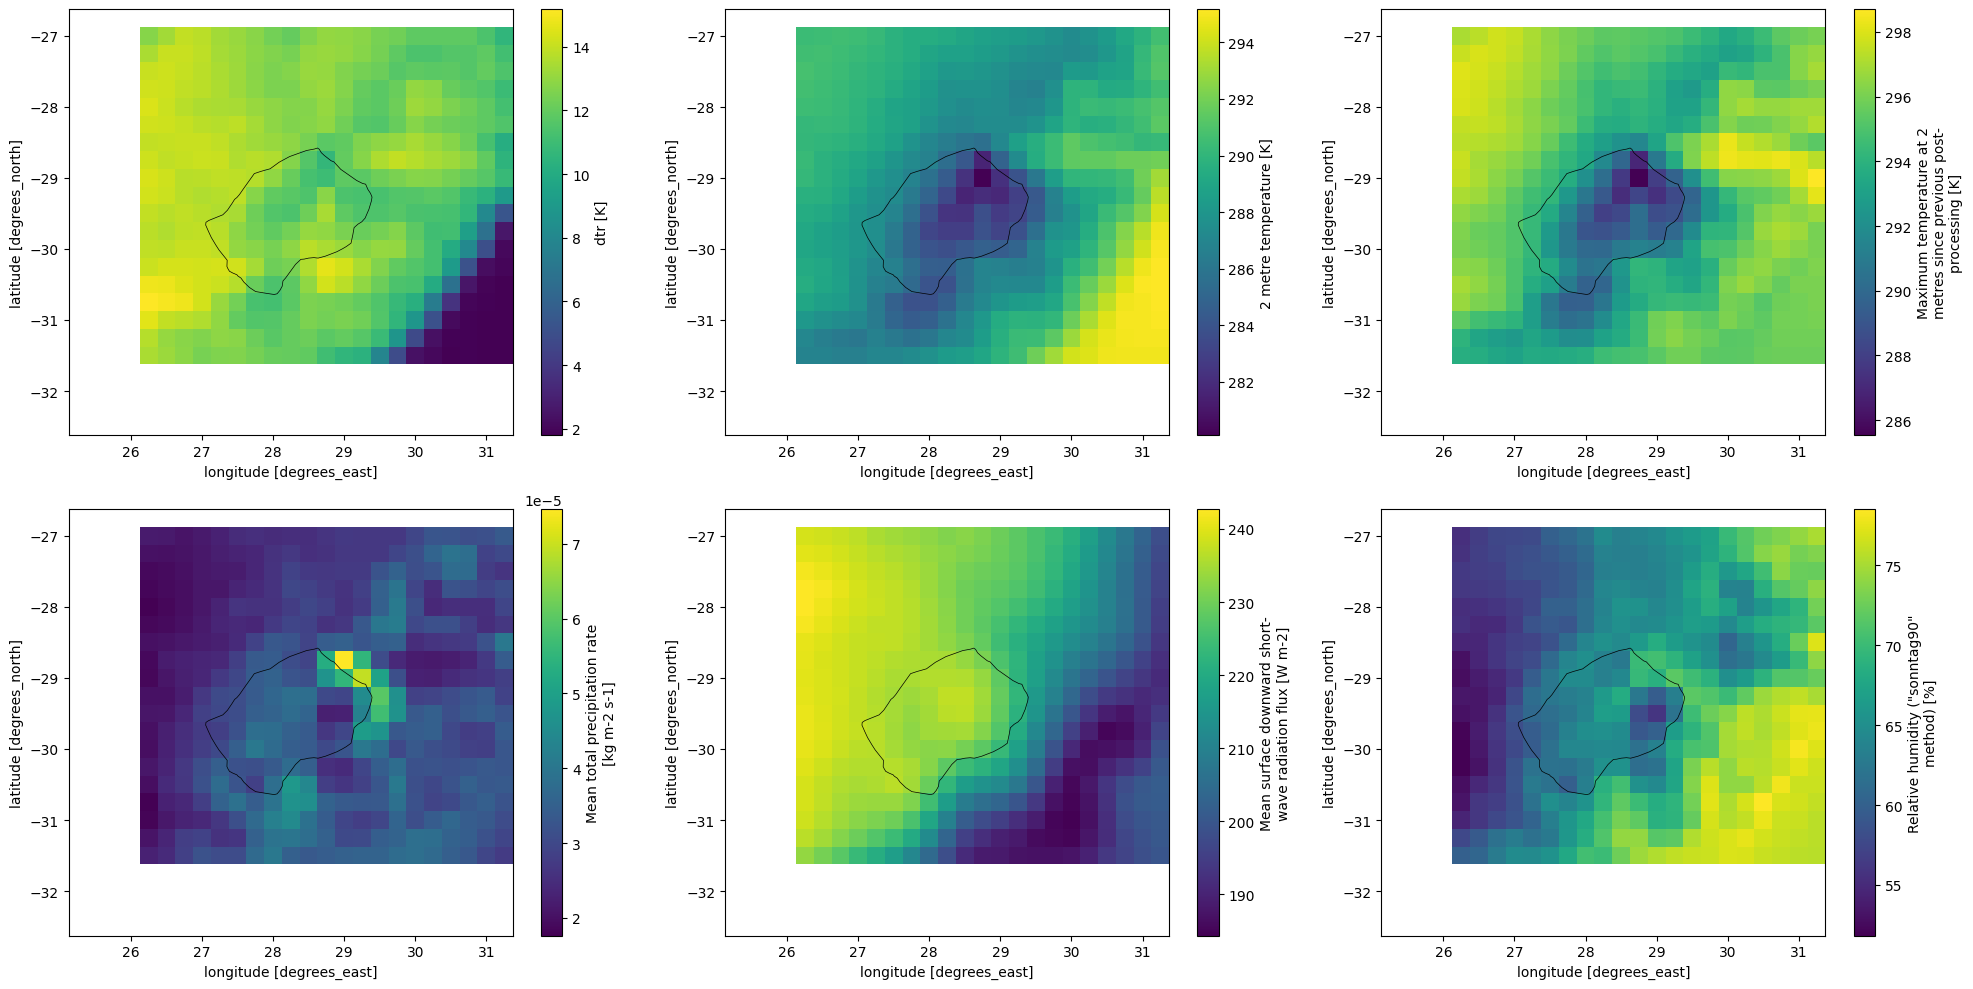

In [24]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

ax = axs[0, 0]
historical_downscaled_dtr.mean(dim="time").plot(ax=ax)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

ax = axs[0, 1]
historical_downscaled_tas.mean(dim="time").plot(ax=ax)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

ax = axs[0, 2]
historical_downscaled_tasmax.mean(dim="time").plot(ax=ax)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

ax = axs[1, 0]
historical_downscaled_pr.mean(dim="time").plot(ax=ax)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

ax = axs[1, 1]
historical_downscaled_rsds.mean(dim="time").plot(ax=ax)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

ax = axs[1, 2]
historical_downscaled_hurs.mean(dim="time").plot(ax=ax)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

plt.tight_layout()
plt.show()

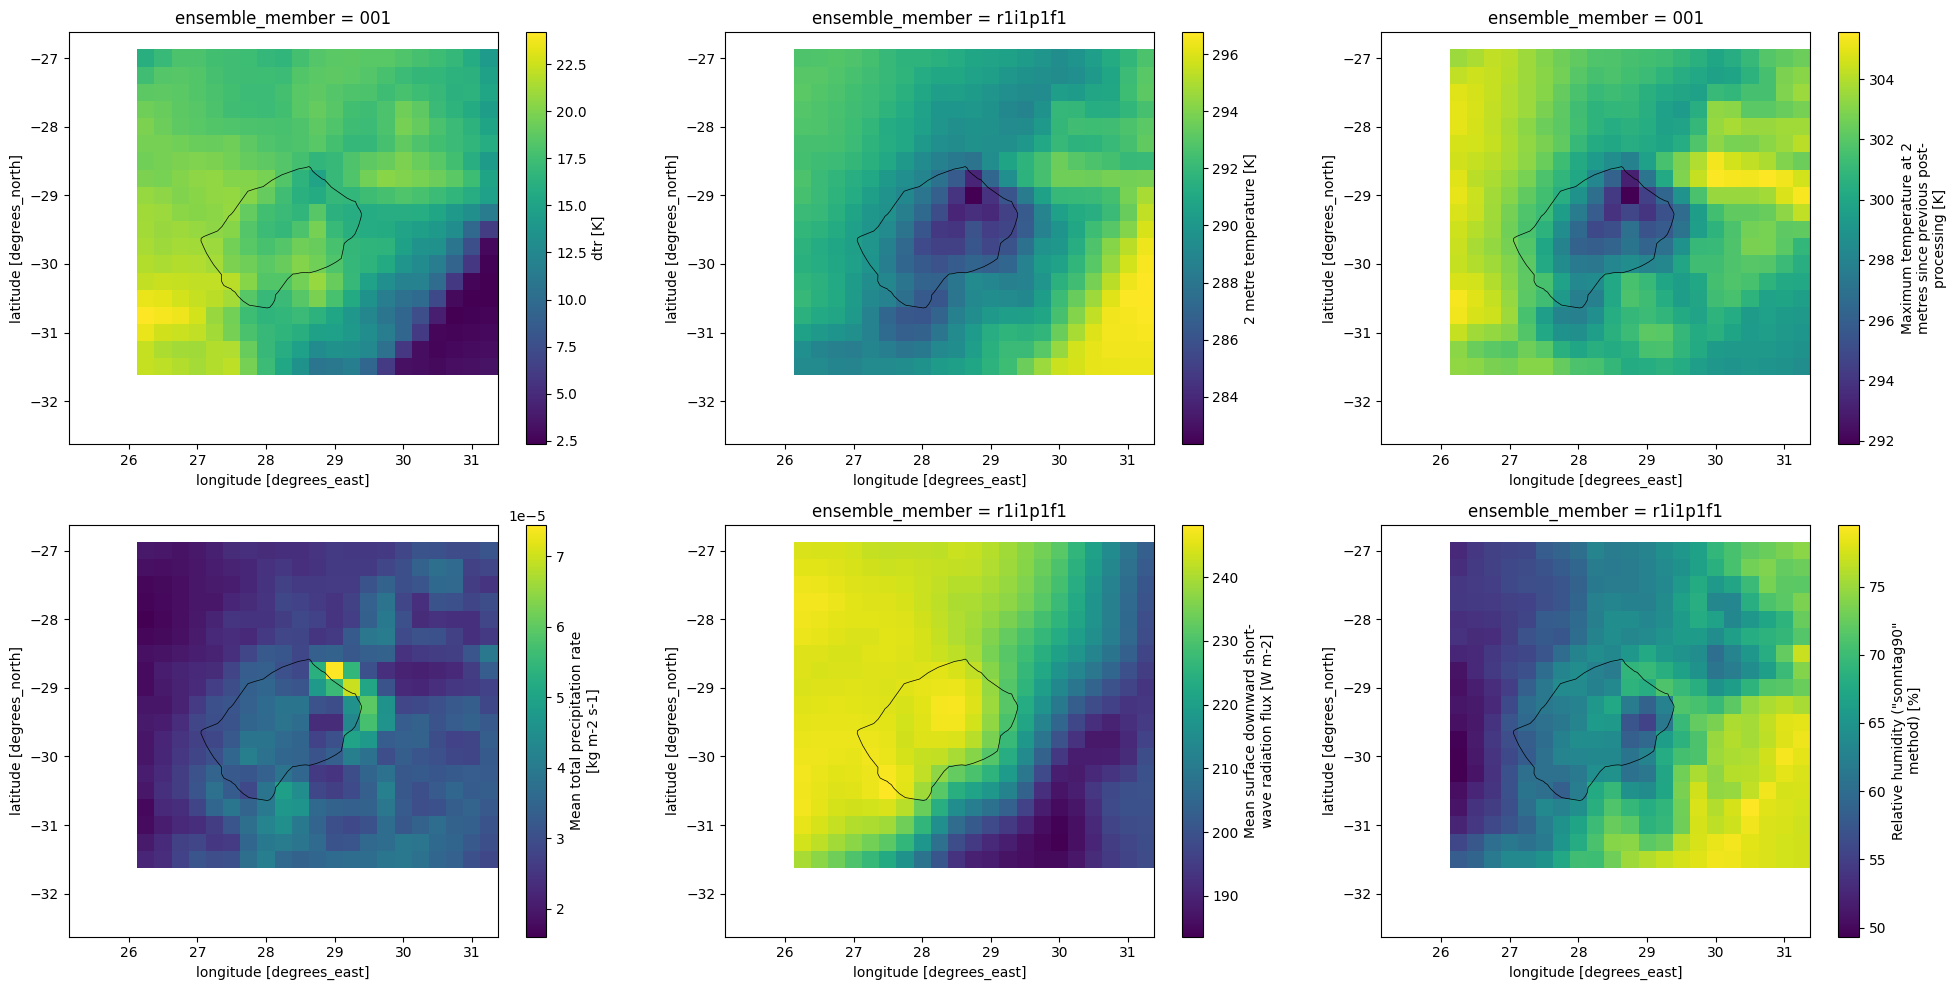

In [25]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

ax = axs[0, 0]
scenario_downscaled_dtr.mean(dim="time").plot(ax=ax)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

ax = axs[0, 1]
scenario_downscaled_tas.mean(dim="time").plot(ax=ax)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

ax = axs[0, 2]
scenario_downscaled_tasmax.mean(dim="time").plot(ax=ax)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

ax = axs[1, 0]
scenario_downscaled_pr.mean(dim="time").plot(ax=ax)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

ax = axs[1, 1]
scenario_downscaled_rsds.mean(dim="time").plot(ax=ax)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

ax = axs[1, 2]
scenario_downscaled_hurs.mean(dim="time").plot(ax=ax)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

plt.tight_layout()
plt.show()

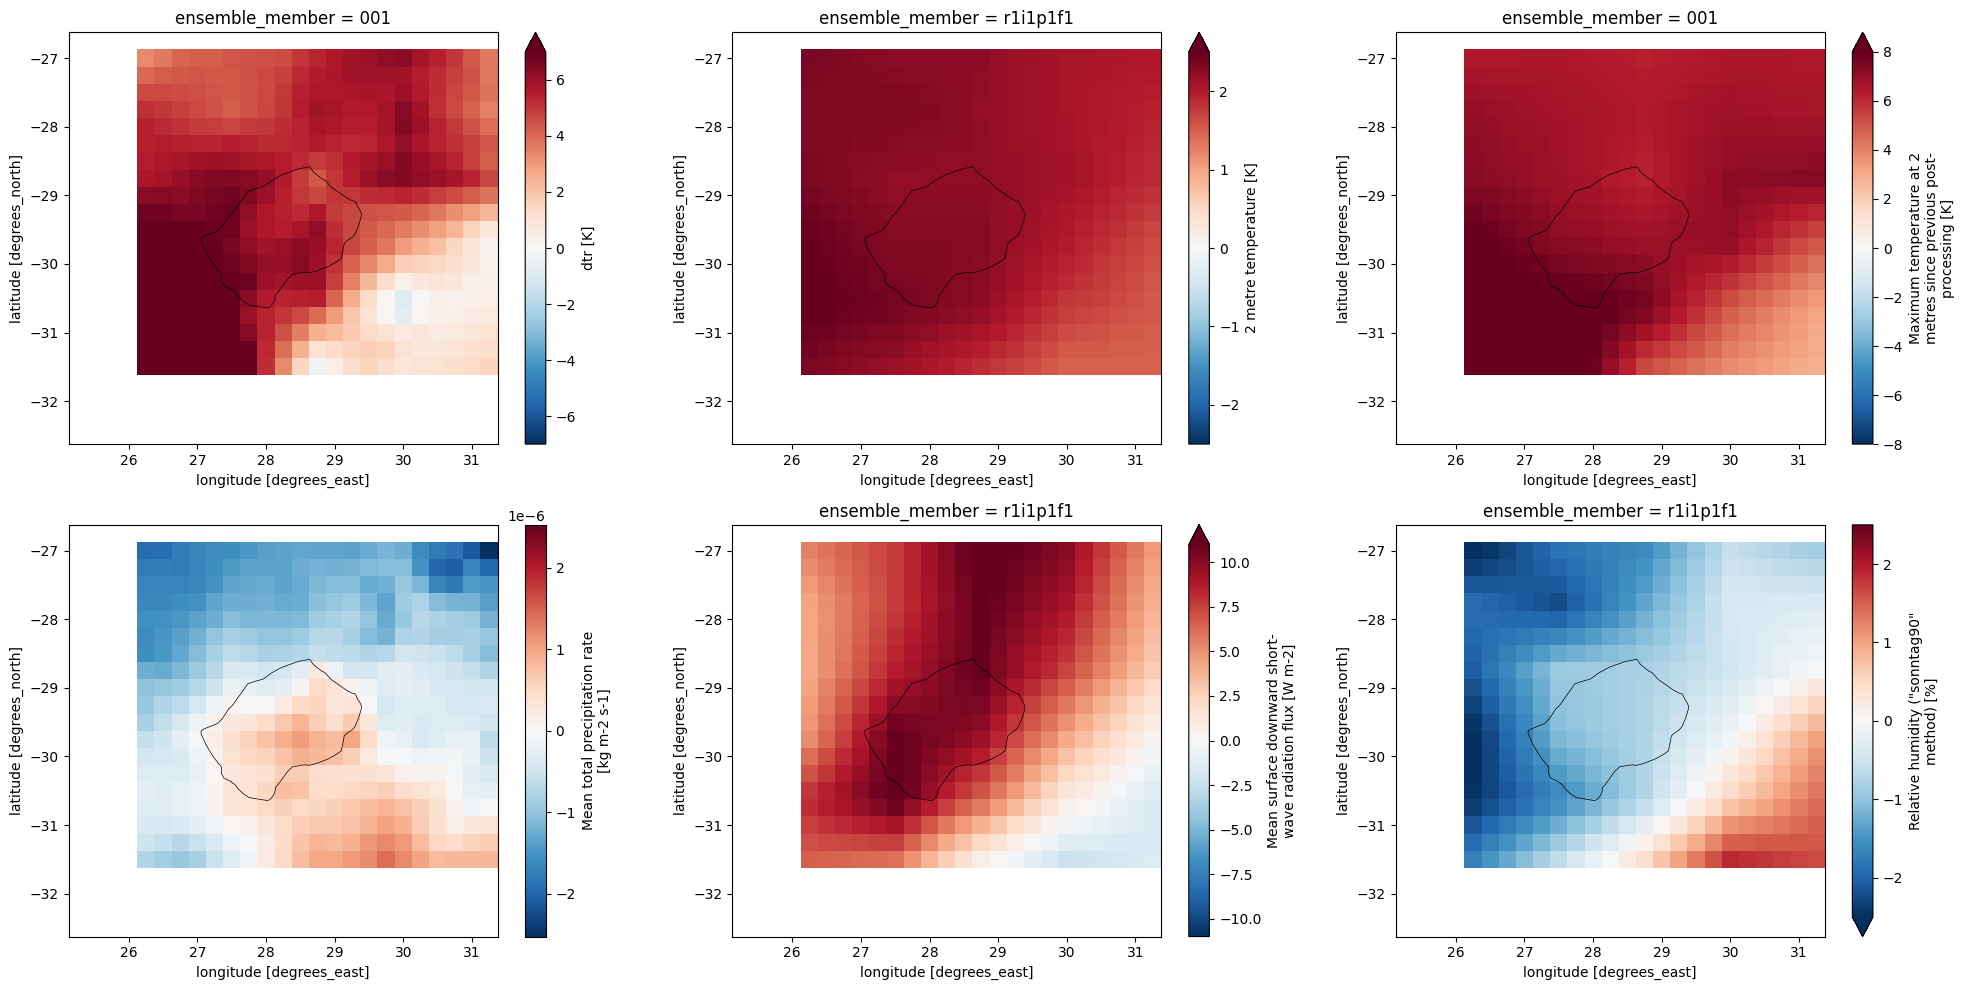

In [29]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

ax = axs[0, 0]
(scenario_downscaled_dtr.mean(dim="time") - historical_downscaled_dtr.mean(dim="time")).plot(
    ax=ax, cmap=plt.cm.RdBu_r, vmax=7
)  # , vmax=16, vmin=-16)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

ax = axs[0, 1]
(scenario_downscaled_tas.mean(dim="time") - historical_downscaled_tas.mean(dim="time")).plot(
    ax=ax, cmap=plt.cm.RdBu_r, vmax=2.5, vmin=-2.5
)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

ax = axs[0, 2]
(scenario_downscaled_tasmax.mean(dim="time") - historical_downscaled_tasmax.mean(dim="time")).plot(
    ax=ax, cmap=plt.cm.RdBu_r, vmax=8, vmin=-8
)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

ax = axs[1, 0]
(scenario_downscaled_pr.mean(dim="time") - historical_downscaled_pr.mean(dim="time")).plot(ax=ax)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

ax = axs[1, 1]
(scenario_downscaled_rsds.mean(dim="time") - historical_downscaled_rsds.mean(dim="time")).plot(
    ax=ax, vmax=11
)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

ax = axs[1, 2]
(scenario_downscaled_hurs.mean(dim="time") - historical_downscaled_hurs.mean(dim="time")).plot(
    ax=ax, vmax=2.5
)
country_geom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

plt.tight_layout()
plt.show()

(-32.0, -26.0)

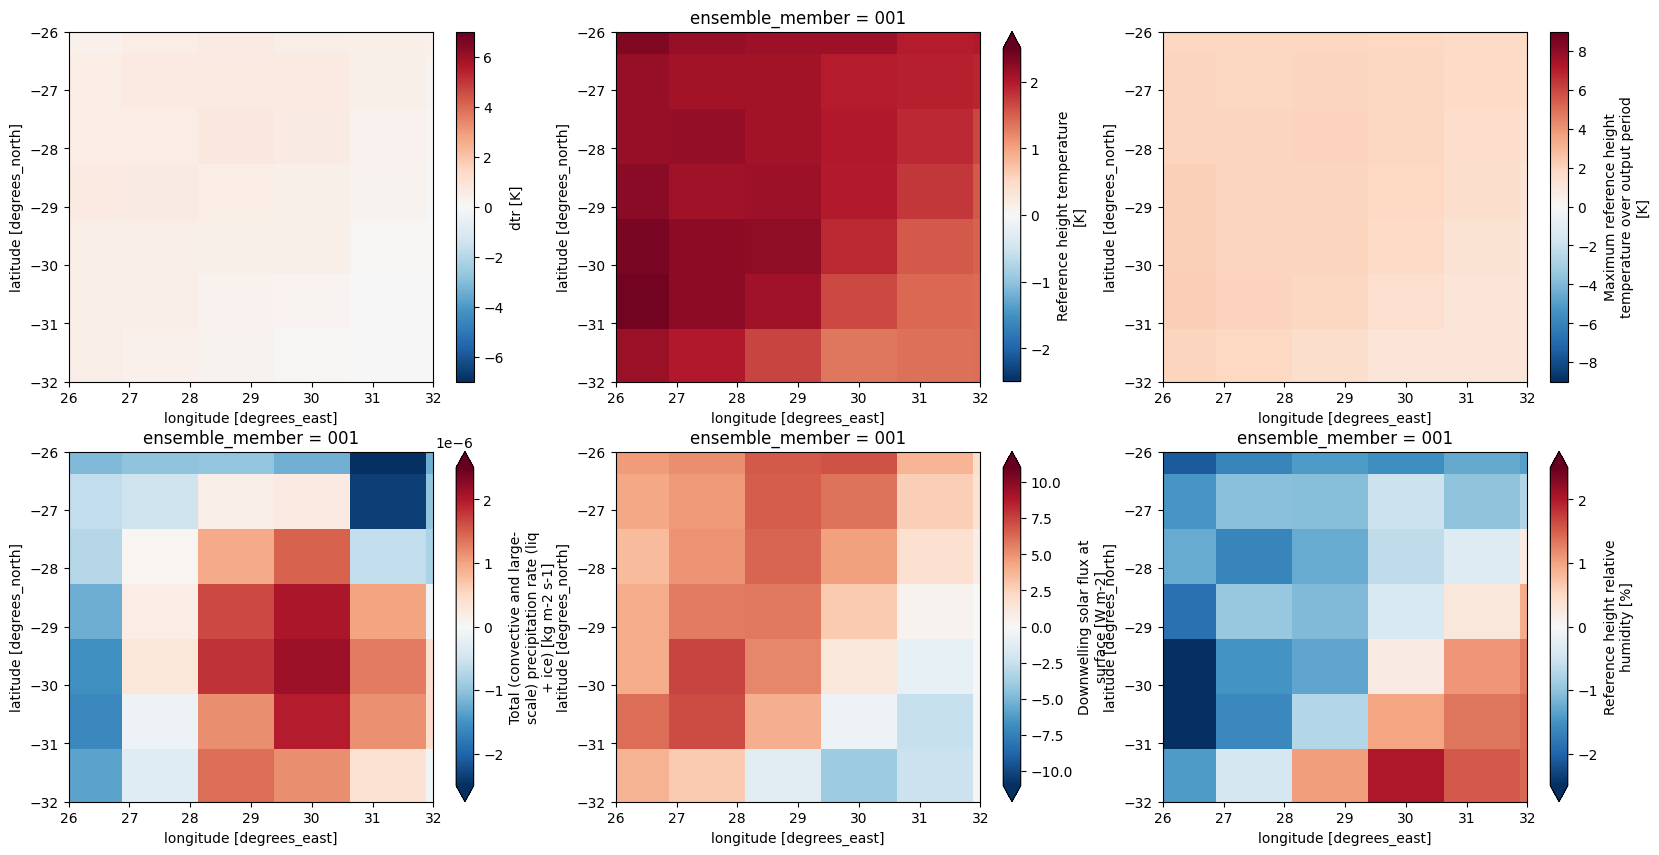

In [28]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

ax = axs[0, 0]
var = "dtr"
delta_map = catalog.get("CESM2-WACCM-SSP245-icechunk").to_xarray().sel(ensemble_member="007")[
    var
].mean(dim="time") - catalog.get("CESM2-WACCM-historical-icechunk").to_xarray().sel(
    ensemble_member="001"
)[var].mean(dim="time")
delta_map.plot(vmax=7, ax=ax)
ax.set_xlim([26, 32])
ax.set_ylim([-32, -26])

ax = axs[0, 1]
var = "tas"
delta_map = catalog.get("CESM2-WACCM-SSP245-icechunk").to_xarray().sel(ensemble_member="001")[
    var
].mean(dim="time") - catalog.get("CESM2-WACCM-historical-icechunk").to_xarray().sel(
    ensemble_member="001"
)[var].mean(dim="time")
delta_map.plot(vmax=2.5, vmin=-2.5, cmap=plt.cm.RdBu_r, ax=ax)
ax.set_xlim([26, 32])
ax.set_ylim([-32, -26])

ax = axs[0, 2]
var = "tasmax"
delta_map = catalog.get("CESM2-WACCM-SSP245-icechunk").to_xarray().sel(ensemble_member="007")[
    var
].mean(dim="time") - catalog.get("CESM2-WACCM-historical-icechunk").to_xarray().sel(
    ensemble_member="001"
)[var].mean(dim="time")
delta_map.plot(vmax=9, vmin=-9, cmap=plt.cm.RdBu_r, ax=ax)
ax.set_xlim([26, 32])
ax.set_ylim([-32, -26])

ax = axs[1, 0]
var = "pr"
delta_map = catalog.get("CESM2-WACCM-SSP245-icechunk").to_xarray().sel(ensemble_member="001")[
    var
].mean(dim="time") - catalog.get("CESM2-WACCM-historical-icechunk").to_xarray().sel(
    ensemble_member="001"
)[var].mean(dim="time")
delta_map.plot(vmax=2.5e-6, ax=ax)
ax.set_xlim([26, 32])
ax.set_ylim([-32, -26])

ax = axs[1, 1]
var = "rsds"
delta_map = catalog.get("CESM2-WACCM-SSP245-icechunk").to_xarray().sel(ensemble_member="001")[
    var
].mean(dim="time") - catalog.get("CESM2-WACCM-historical-icechunk").to_xarray().sel(
    ensemble_member="001"
)[var].mean(dim="time")
delta_map.plot(vmax=11, ax=ax)
ax.set_xlim([26, 32])
ax.set_ylim([-32, -26])

ax = axs[1, 2]
var = "hurs"
delta_map = catalog.get("CESM2-WACCM-SSP245-icechunk").to_xarray().sel(ensemble_member="001")[
    var
].mean(dim="time") - catalog.get("CESM2-WACCM-historical-icechunk").to_xarray().sel(
    ensemble_member="001"
)[var].mean(dim="time")
delta_map.plot(ax=ax, vmax=2.5)
ax.set_xlim([26, 32])
ax.set_ylim([-32, -26])